In [49]:
!pip install matplotlib
!pip install "numpy<2" --force-reinstall
!pip install torch


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
  Using cached numpy-1.26.4-cp312-cp312-macosx_10_9_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-macosx_10_9_x86_64.whl (20.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [50]:
import torch
import numpy as np
import scipy.io
from sklearn.linear_model import Ridge
import yfinance as yf

In [51]:
# ── 1. Load Heston parameters from MATLAB ─────────────────────────────────────
mat   = scipy.io.loadmat('heston_params.mat')
Param = mat['Param'].flatten()
V0, ThetaV, Kappa, SigmaV, RhoSV = Param
r = -0.001


In [52]:
# ── 2. Simulate ALL V(t) paths once (Monte Carlo) ─────────────────────────────
dt      = 1/252
T       = 3.0
n_steps = int(T / dt)
n_paths = 5000         # all paths generated once, reused everywhere

torch.manual_seed(42)

# Pre-generate ALL random shocks for the entire simulation upfront
# Shape: (n_steps, n_paths) — reused for mu fitting AND ANN training
dW_V_all = torch.randn(n_steps, n_paths) * (dt**0.5)  # variance shocks
dW_S_all = torch.randn(n_steps, n_paths) * (dt**0.5)  # price shocks

# Simulate all V(t) paths
V_paths = torch.zeros(n_steps + 1, n_paths)
V_paths[0] = V0

for t in range(n_steps):
    V_prev = V_paths[t]
    # Since we didn't check the Feller condition (2*Kappa*ThetaV>SigmaV**2), we clamp V to be non-negative to avoid numerical issues
    V_paths[t+1] = torch.clamp(
        V_prev + Kappa*(ThetaV - V_prev)*dt
               + SigmaV*torch.sqrt(V_prev.clamp(min=0))*dW_V_all[t], 
        min=1e-6
    )


# V_paths shape: (n_steps+1, n_paths)
# Every subsequent step just reads from this tensor — no re-simulation


In [53]:
# ── 3. Estimate mu(V) = alpha + beta*V from TSLA historical data ───────────────
tsla       = yf.download('TSLA', start='2015-07-10', end='2015-09-30')
prices     = tsla['Close'].values
log_ret_raw    = np.diff(np.log(prices),axis=0)
log_ret = log_ret_raw[~np.isnan(log_ret_raw)]
print(np.shape(prices))
print(log_ret_raw)
window = 10
mu_roll, V_roll = [], []
for i in range(window, len(log_ret)):
    mu_roll.append(np.mean(log_ret[i-window:i]) * 252)
    V_roll.append(np.var(log_ret[i-window:i])   * 252)

mu_roll = np.array(mu_roll).reshape(-1, 1)
V_roll  = np.array(V_roll).reshape(-1, 1)

reg   = Ridge(alpha=0.1).fit(V_roll, mu_roll)  # Ridge for stability
alpha_mu = float(reg.intercept_)
beta_mu  = float(reg.coef_[0])

print(f"mu(V) = {alpha_mu:.4f} + {beta_mu:.4f} * V(t)")

[*********************100%***********************]  1 of 1 completed

(57, 1)
[[ 0.01154795]
 [ 0.01322461]
 [-0.00949335]
 [ 0.01336323]
 [ 0.02948451]
 [ 0.02729464]
 [-0.0564418 ]
 [ 0.00411495]
 [-0.00250433]
 [-0.00672164]
 [-0.04784685]
 [ 0.0456214 ]
 [-0.00378335]
 [ 0.01119478]
 [-0.00240171]
 [-0.02341693]
 [ 0.02390528]
 [ 0.01435491]
 [-0.09304349]
 [-0.01481688]
 [-0.00566527]
 [-0.01575757]
 [ 0.0033646 ]
 [ 0.01805824]
 [ 0.00263552]
 [ 0.0475458 ]
 [ 0.02222271]
 [-0.02120354]
 [-0.05256225]
 [-0.0482596 ]
 [-0.05294364]
 [ 0.00528596]
 [ 0.02162511]
 [ 0.07763126]
 [ 0.02234202]
 [ 0.00233153]
 [-0.04277961]
 [ 0.03726373]
 [-0.008596  ]
 [-0.01493347]
 [ 0.02546547]
 [ 0.0029774 ]
 [-0.00172907]
 [ 0.00705816]
 [ 0.01171974]
 [ 0.00149973]
 [ 0.03365833]
 [-0.00068666]
 [-0.00554822]
 [ 0.01364298]
 [-0.01241587]
 [ 0.00045974]
 [ 0.00785991]
 [-0.02388435]
 [-0.03356466]
 [-0.00719084]]
mu(V) = 0.9240 + -4.8930 * V(t)



/var/folders/04/b10wc84x5dg_ysjt5_37kmvw0000gn/T/ipykernel_2424/355543009.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  alpha_mu = float(reg.intercept_)


In [54]:
# ── 4. Compute mu(t) paths directly from V_paths ──────────────────────────────
# Shape: (n_steps+1, n_paths) — no re-simulation needed
mu_paths = alpha_mu + beta_mu * V_paths

In [ ]:
W_analytic = torch.ones(n_paths)

for t in range(n_steps):

    V_t  = V_paths[t]       # read from pre-simulated V tensor
    mu_t = mu_paths[t]      # read from pre-computed mu tensor
    dW_S = dW_S_all[t]      # read pre-generated shock

    # Analytic Merton pi
    with torch.no_grad():
        pi_analytic = ((mu_t - r) / (gamma * V_t)).clamp(0, 1)
        # 0.5*pi_analytic**2*V_t is the correction from Ito's Lemma becuase we took the log of wealth/returns, not wealth itself
        W_analytic  = W_analytic * torch.exp(
            (r + pi_analytic*(mu_t - r) - 0.5*pi_analytic**2*V_t)*dt 
            + pi_analytic*torch.sqrt(V_t)*dW_S
        )

    

# Loss over all Monte Carlo paths
loss = -torch.mean(W_ann**(1 - gamma) / (1 - gamma))


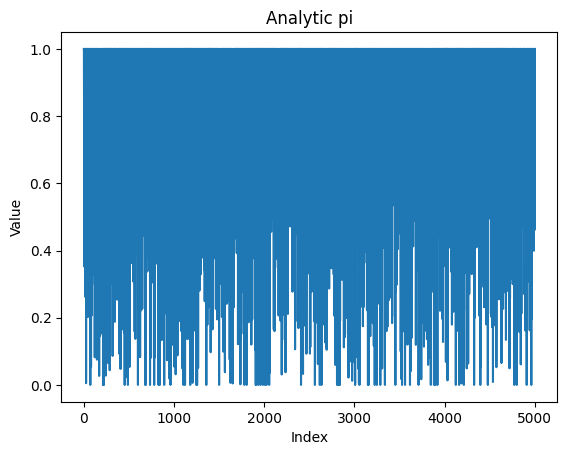

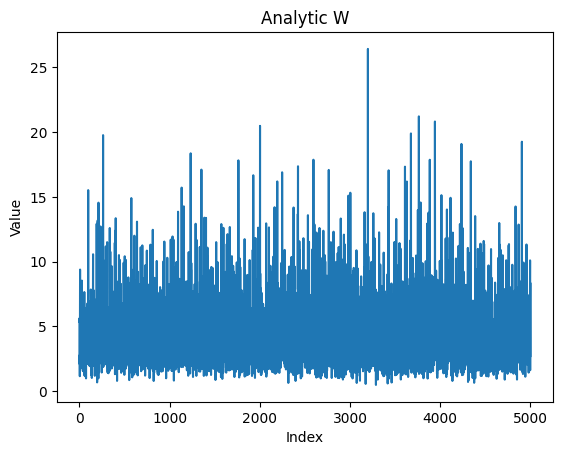

In [56]:
#ANALYTIC----------

import torch
import numpy
import matplotlib.pyplot as plt

#pi----------------

# Convert to numpy for plotting
data = pi_analytic.numpy()

# Plot
plt.plot( data)
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Analytic pi")
plt.show()

#W----------------

# Convert to numpy for plotting
data = W_analytic.detach().numpy()

# Plot
plt.plot( data)
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Analytic W")
plt.show()


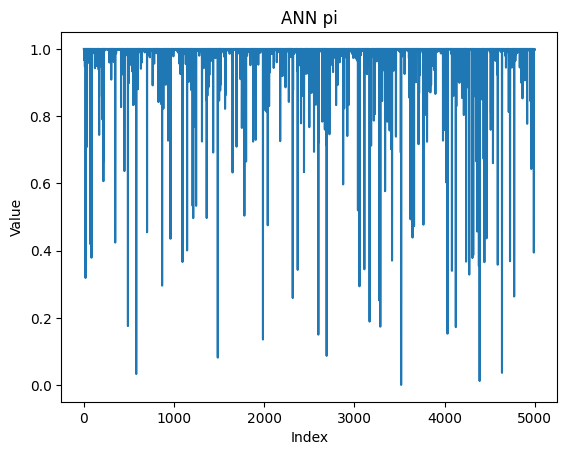

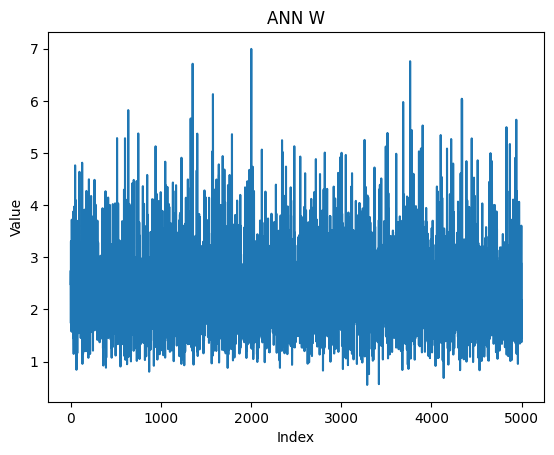

In [57]:
#ANN---------------

import torch
import numpy
import matplotlib.pyplot as plt

#pi----------------

# Convert to numpy for plotting
data = pi_ann.detach().numpy()

# Plot
plt.plot( data)
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("ANN pi")
plt.show()

#W----------------

# Convert to numpy for plotting
data = W_ann.detach().numpy()

# Plot
plt.plot( data)
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("ANN W")
plt.show()



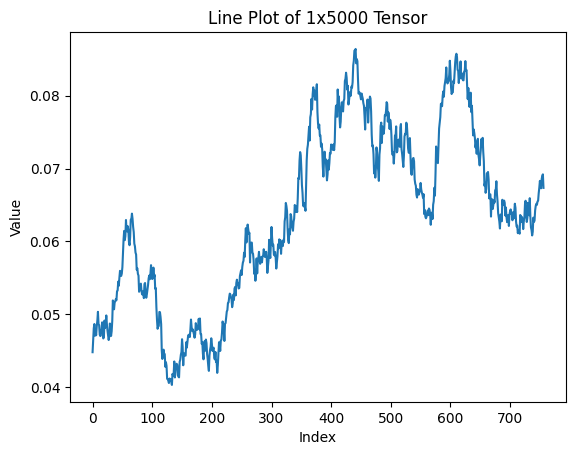

In [ ]:
import torch
import numpy
import matplotlib.pyplot as plt

# Convert to numpy for plotting
data = V_paths[:, 1]

# Plot
plt.plot( data)
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Line Plot of 1x5000 Tensor")
plt.show()

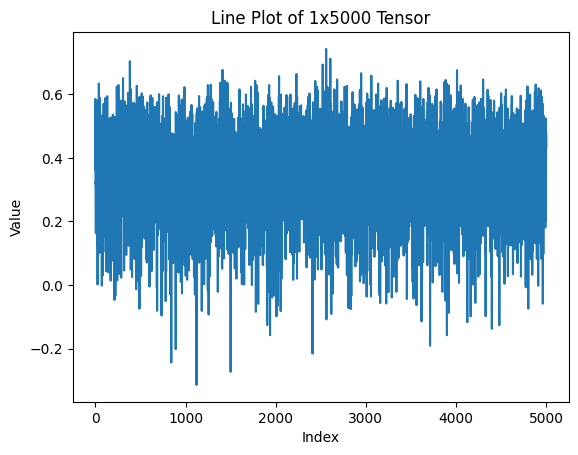

In [59]:
import torch
import numpy
import matplotlib.pyplot as plt

# Convert to numpy for plotting
data = mu_t.detach().numpy()


# Plot
plt.plot( data)
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Line Plot of 1x5000 Tensor")
plt.show()

In [60]:
# import dill 

# dill.load_session('placeholder_param_dump.db')